In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression
from sklearn.metrics import mean_absolute_error

import sys
import os
sys.path.append(os.path.abspath("../src"))
from linear_regression import LinearRegression

In [2]:
# Generate Data
X, y = make_regression(
    n_samples=1000, n_features=10, n_informative=5, noise=10, random_state=42
)

# Simulate real-world scale differences across features
X[:, 0] = X[:, 0] * 10000
X[:, 1] = X[:, 1] * 0.001

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

## Feature Scaling

In [3]:
# Apply & Verify Feature Scaling
model = LinearRegression()
X_train_scaled = model.feature_scaling(X_train)
X_test_scaled = (X_test - model.X_mean) / model.X_std

print(f"Before → Mean: {X_train.mean():.2f}  Std: {X_train.std():.2f}")
print(f"After  → Mean: {X_train_scaled.mean():.2f}  Std: {X_train_scaled.std():.2f}")

Before → Mean: -18.98  Std: 3200.25
After  → Mean: 0.00  Std: 1.00


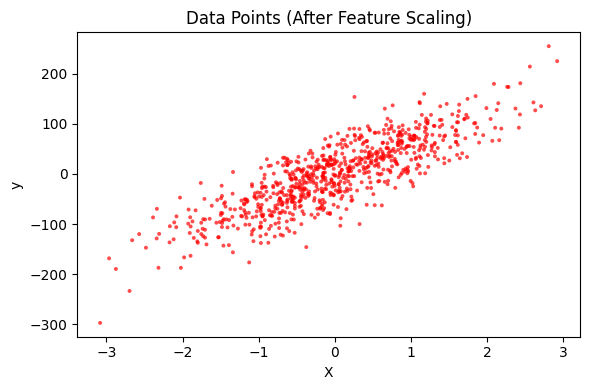

In [4]:
# Data Points After Scaling
plt.figure(figsize=(6, 4))
plt.scatter(
    X_train_scaled[:, 0], y_train, color="red", s=8, alpha=0.7, edgecolors="none"
)
plt.title("Data Points (After Feature Scaling)")
plt.xlabel("X")
plt.ylabel("y")
plt.tight_layout()
plt.show()

## Finding the Best Learning Rate

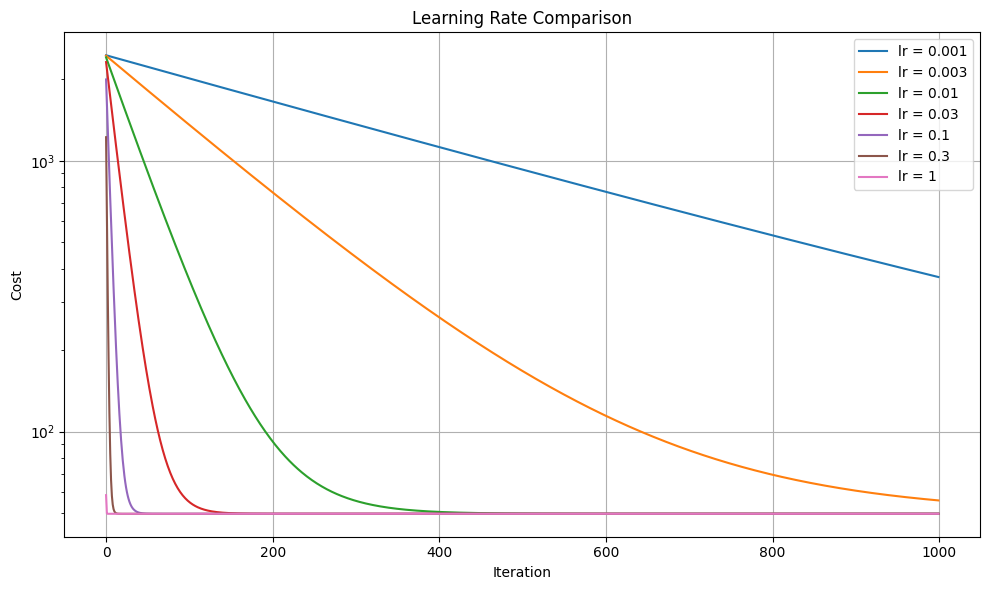

In [5]:
# Learning Rate Comparison
learning_rates = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1]

plt.figure(figsize=(10, 6))
for lr in learning_rates:
    m = LinearRegression(learning_rate=lr, iterations=1000)
    m.fit(X_train_scaled, y_train)
    plt.plot(m.cost_history, label=f"lr = {lr}")

plt.title("Learning Rate Comparison")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.yscale("log")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Finding the Best L2 Lambda

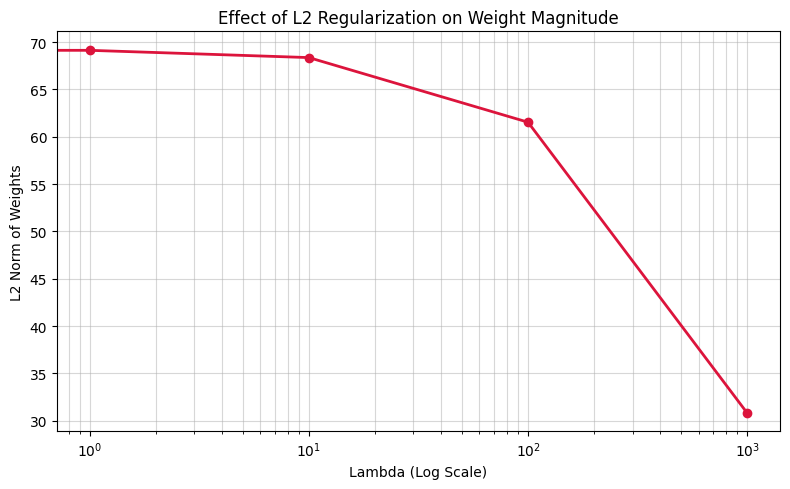

(None, None)

In [6]:
# L2 Regularization Comparison
lambdas = [0, 1, 10, 100, 1000]
weight_magnitudes = []

for l2 in lambdas:
    m = LinearRegression(learning_rate=0.1, iterations=500, l2_lambda=l2)
    m.fit(X_train_scaled, y_train)
    weight_magnitudes.append(np.linalg.norm(m.w))

plt.figure(figsize=(8, 5))
plt.plot(lambdas, weight_magnitudes, marker="o", color="crimson", linewidth=2)
plt.xscale("log")
plt.title("Effect of L2 Regularization on Weight Magnitude")
plt.xlabel("Lambda (Log Scale)"), plt.ylabel("L2 Norm of Weights")
plt.grid(True, which="both", alpha=0.5)
plt.tight_layout(), plt.show()

## Train Final Model

In [7]:
# Train & Evaluate
model = LinearRegression(learning_rate=0.03, iterations=1000, l2_lambda=0.1)
model.fit(X_train_scaled, y_train)

train_preds = model.predict(X_train_scaled)
test_preds = model.predict(X_test_scaled)

print(f"Train MAE: {mean_absolute_error(y_train, train_preds):.4f}")
print(f"Test  MAE: {mean_absolute_error(y_test,  test_preds):.4f}")

Train MAE: 7.9897
Test  MAE: 7.1947


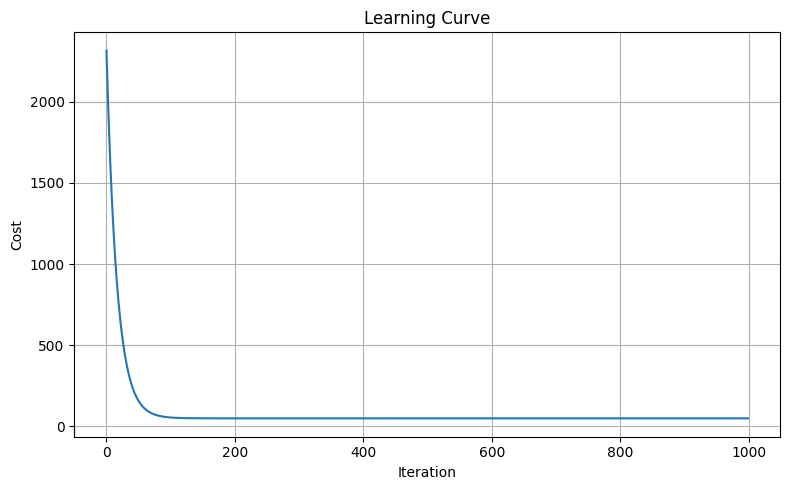

(None, None, None)

In [8]:
# Learning Curve
plt.figure(figsize=(8, 5))
plt.plot(model.cost_history)
plt.title("Learning Curve"), plt.xlabel("Iteration"), plt.ylabel("Cost")
plt.grid(True), plt.tight_layout(), plt.show()

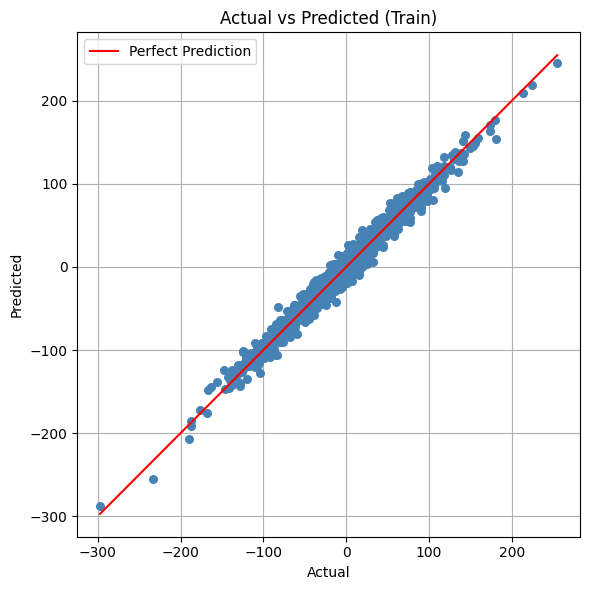

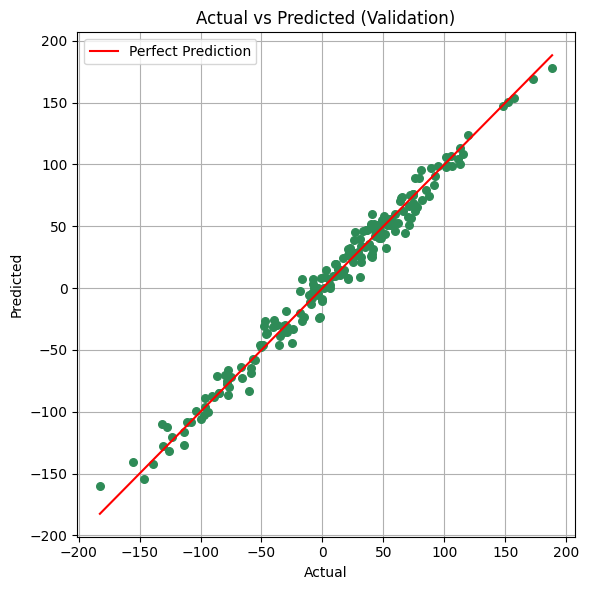

In [9]:
# Actual vs Predicted
for preds, labels, title, color in [
    (train_preds, y_train, "Train", "steelblue"),
    (test_preds, y_test, "Validation", "seagreen"),
]:
    plt.figure(figsize=(6, 6))
    plt.scatter(labels, preds, color=color, s=30, zorder=3)
    lims = [min(labels.min(), preds.min()), max(labels.max(), preds.max())]
    plt.plot(lims, lims, "r", label="Perfect Prediction", zorder=4)
    plt.title(f"Actual vs Predicted ({title})")
    plt.xlabel("Actual"), plt.ylabel("Predicted")
    plt.legend(), plt.grid(True), plt.tight_layout(), plt.show()